In [1]:
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [2]:
function import_TIRA(file_path)
    
    df=CSV.read(file_path,DataFrame) 
    df.Zeit = parse.(Float64, replace.(df.Zeit, "," => "."))
    df.Länge = parse.(Float64, replace.(df.Länge, "," => "."))
    df.Weg = parse.(Float64, replace.(df.Weg, "," => "."))
    #df.Dehnung = parse.(Float64, replace.(df.Dehnung, "," => "."))
    df.Kraft = parse.(Float64, replace.(df.Kraft, "," => "."))
    df.dL_ORG = parse.(Float64, replace.(df.dL_ORG, "," => "."))

    return df

end

function filter_range(df::DataFrame, column::String, low, high)
    return filter(row -> low ≤ row[column] ≤ high, df)
end

filter_range (generic function with 1 method)

## Material properties

### Polyimide

In [3]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Polyimide/Dharmadasa2020.csv"

df_Dharmadasa2020 = CSV.read(BaseName, DataFrame;
    delim=',',
    decimal='.'
);

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Polyimide/Dharmadasa2020.csv" is not a valid file or doesn't exist

In [21]:
fig = Figure(resolution = (1000, 600));

font=42
ax1 = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 220)))



Axis with 0 plots:


In [22]:
    Makie.scatter!(ax1,df_Dharmadasa2020[!,1]*100,df_Dharmadasa2020[!,2];
      label = "Polyimide (Dharmadasa, 2020)",
      marksize=10,
      color = :purple,
      clip = true,
      marker = :rect)
    #axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
      #fig

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [23]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Polyimide/Seonho2022.csv"

df_Seonho2022 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [24]:
    Makie.scatter!(ax1,df_Seonho2022[!,1],df_Seonho2022[!,2];
      label = "Polyimide (Seonho, 2022)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :cross)
    #axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
      #fig

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [25]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Polyimide/Kuo2005_0_6.csv"

df_Kuo2005_0_6 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [26]:
    Makie.scatter!(ax1,df_Kuo2005_0_6[!,1],df_Kuo2005_0_6[!,2];
      label = "Polyimide 0.6 %/min (Kuo, 2005)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :diamond)
    #axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
      #fig

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [27]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Polyimide/Kuo2005_60.csv"

df_Kuo2005_60 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

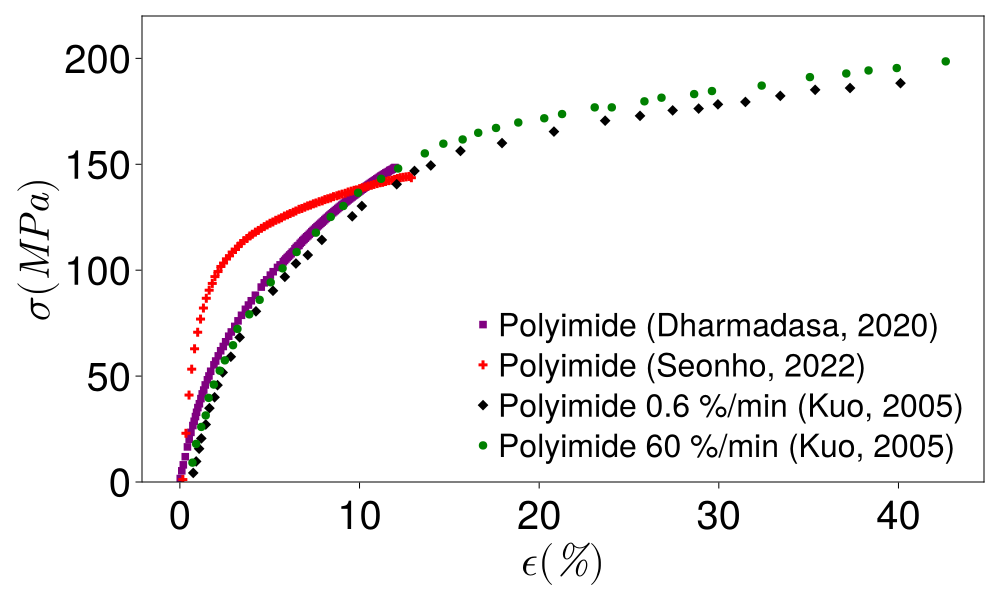

In [28]:
    Makie.scatter!(ax1,df_Kuo2005_60[!,1],df_Kuo2005_60[!,2];
      label = "Polyimide 60 %/min (Kuo, 2005)",
      marksize=10,
      color = :green,
      clip = true,
      marker = :circle)
     axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
      fig

### Parylene

In [49]:
figParylene = Figure(resolution = (1000, 600));

font=42
axParylene = Axis(figParylene[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 75)))


Axis with 0 plots:


In [50]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Parylene/Kang2013_9um_20T.csv"

df_Kang2013 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

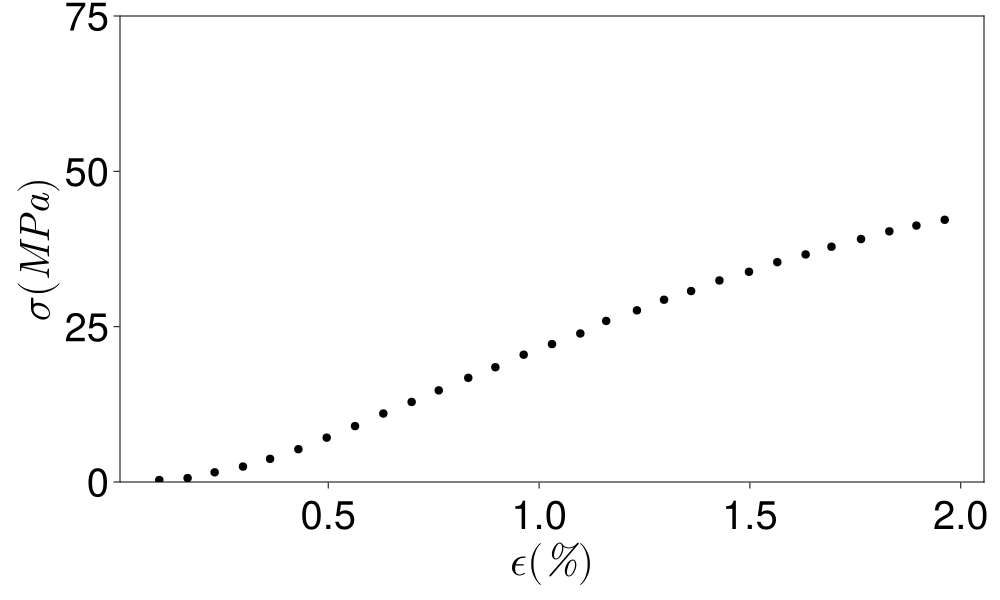

In [51]:
    Makie.scatter!(axParylene,df_Kang2013[!,1],df_Kang2013[!,2];
      label = "Parylene v=1 %/min (Kang, 2013)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)
     #axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      figParylene

In [52]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Parylene/Kohler2023.csv"

df_Kohler2023 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

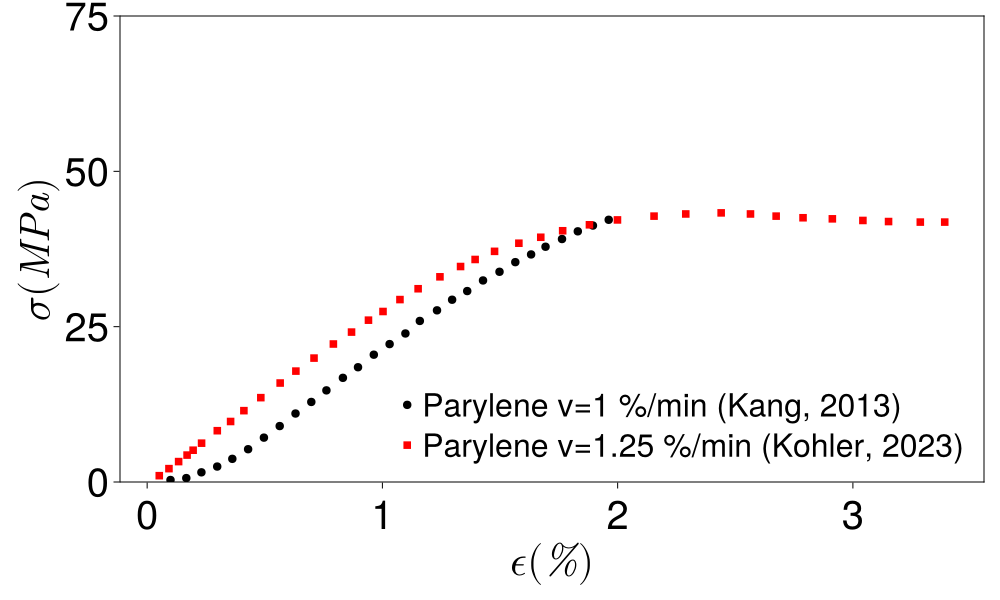

In [53]:
  Makie.scatter!(axParylene,df_Kohler2023[!,1],df_Kohler2023[!,2];
      label = "Parylene v=1.25 %/min (Kohler, 2023)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      figParylene

In [54]:
    ##### Strain Rate 1.43 %/min

    BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
    name="251006-"
    df_Group=[]
    df_Group_Total=[]

    for i in [1]
            file_path = "$(BaseName)$(i).csv"
            df=import_TIRA(file_path)
            df[!,:Name]=fill("$(name)$(i)", nrow(df))
            df[!,:Stress]=df[!,:Kraft]*1e-6/As
              df[!,:Strain]=df[!,:Weg]/100
            df_filtered=filter_range(df,"Weg",0.01,50)
            push!(df_Group,df_filtered)
            push!(df_Group_Total,df_filtered)
    end

    df_Group
    push!(σ_exp,df_Group[1][!,:Stress]*1e6)
    push!(ϵ_exp,df_Group[1][!,:Strain])
    push!(dϵdt,0.0143/60)

4-element Vector{Any}:
 0.00023833333333333334
 0.00074
 0.0045049999999999995
 0.00023833333333333334

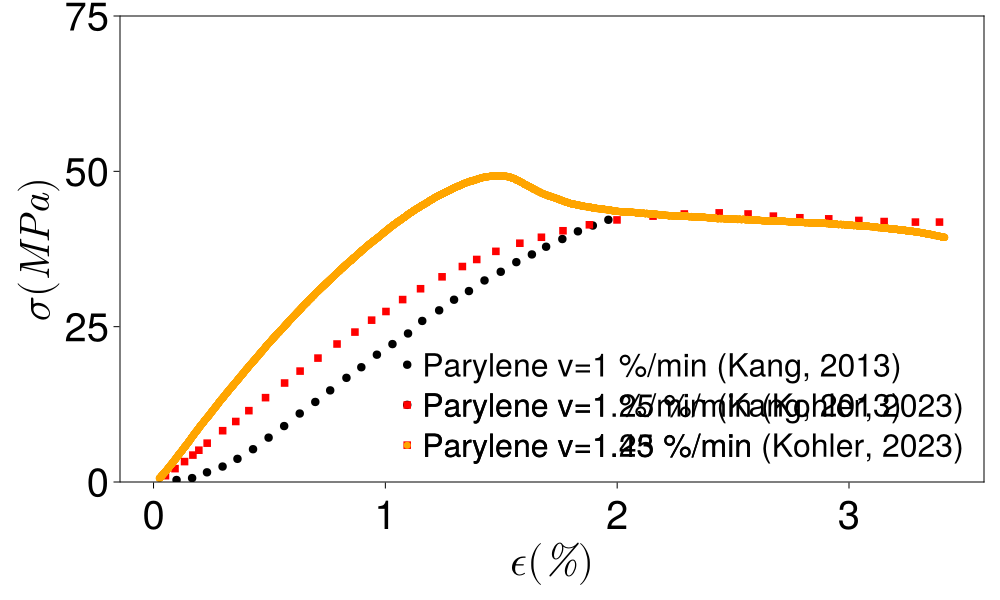

In [55]:
    Makie.scatter!(axParylene ,ϵ_exp[1]*100,σ_exp[1]/1e6;
     markersize=10, 
     label = "Parylene v=$(round(dϵdt[1]*60*100, digits=3)) %/min ",
     color = :orange,
     clip = true)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
     figParylene

### Unseres Parylene

In [43]:
function import_TIRA(file_path)
    
    df=CSV.read(file_path,DataFrame) 
    df.Zeit = parse.(Float64, replace.(df.Zeit, "," => "."))
    df.Länge = parse.(Float64, replace.(df.Länge, "," => "."))
    df.Weg = parse.(Float64, replace.(df.Weg, "," => "."))
    df.Kraft = parse.(Float64, replace.(df.Kraft, "," => "."))
    df.dL_ORG = parse.(Float64, replace.(df.dL_ORG, "," => "."))

    return df

end

function filter_range(df::DataFrame, column::String, low, high)
    return filter(row -> low ≤ row[column] ≤ high, df)
end


filter_range (generic function with 1 method)

#### Temperatur Einfluss

In [44]:
fig2 = Figure(resolution = (1000, 600));

ax1_2 = Axis(fig2[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


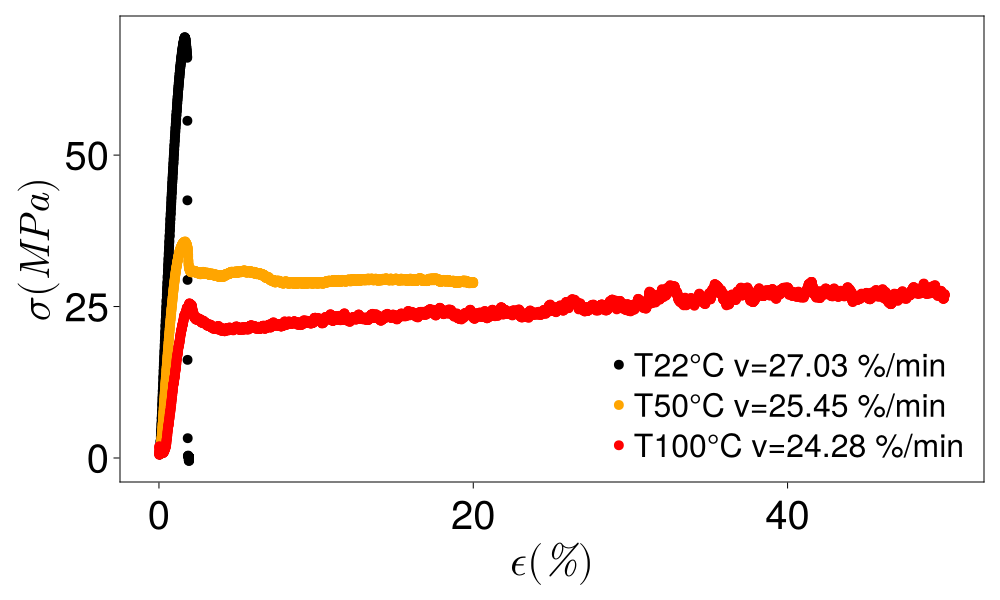

In [45]:
## Fig2 Temperatur Einfluss

## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness
l=60*1e-3 # length
As=w*t    # stress section


σ_exp=[]
ϵ_exp=[]
dϵdt=[]
## Room 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]

df_Group_Total=[]

for i in [1]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=(df[!,:Weg])
        df_filtered=filter_range(df,"Strain",0,20)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2703/60)

## 50 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [7]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=(df[!,:Weg])
        df_filtered=filter_range(df,"Strain",0,20)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2545/60)


## 100 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [10]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:dL_ORG]=df[!,:dL_ORG].-0.6
        df[!,:Strain]=df[!,:Weg]
        df_filtered=filter_range(df,"Strain",0,50)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2428/60)


## Fig2


    Makie.scatter!(ax1_2 ,ϵ_exp[1],σ_exp[1]/1e6;
     markersize=14, 
     label = "T22°C v=$(round(dϵdt[1]*60*100, digits=3)) %/min",
     color = :black)
    
    Makie.scatter!(ax1_2,ϵ_exp[2],σ_exp[2]/1e6;
      label = "T50°C v=$(round(dϵdt[2]*60*100, digits=3)) %/min",
      markersize=14,
      color = :orange)
    
    Makie.scatter!(ax1_2,ϵ_exp[3],σ_exp[3]/1e6;
    label = "T100°C v=$(round(dϵdt[3]*60*100, digits=3)) %/min",
    markersize=14, 
    color = :red)
    axislegend(ax1_2, labelsize=font-10, framevisible=false,position = :rb)

    fig2


#### Strain Rate Einfluss

In [46]:
## Fig3 Strain Rate Einfluss
figStrainRate = Figure(resolution = (1000, 600));
axStrainRate = Axis(figStrainRate[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

σ_exp=[]
ϵ_exp=[]
dϵdt=[]




    ##### Strain Rate 1.43 %/min

    BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
    name="251006-"
    df_Group=[]
    df_Group_Total=[]

    for i in [1]
            file_path = "$(BaseName)$(i).csv"
            df=import_TIRA(file_path)
            df[!,:Name]=fill("$(name)$(i)", nrow(df))
            df[!,:Stress]=df[!,:Kraft]*1e-6/As
              df[!,:Strain]=df[!,:Weg]/100
            df_filtered=filter_range(df,"Weg",0.01,50)
            push!(df_Group,df_filtered)
            push!(df_Group_Total,df_filtered)
    end

    df_Group
    push!(σ_exp,df_Group[1][!,:Stress]*1e6)
    push!(ϵ_exp,df_Group[1][!,:Strain])
    push!(dϵdt,0.0143/60)



##### Strain Rate 4.44 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
name="251006-"
df_Group=[]
df_Group_Total=[]

for i in [6]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:Weg]/100
        df_filtered=filter_range(df,"Weg",0.01,50)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

df_Group
push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.0444/60)


### Strain rate 27%
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [1]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:Weg]/100
        df_filtered=filter_range(df,"Weg",0.01,50)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end


push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2703/60)

3-element Vector{Any}:
 0.00023833333333333334
 0.00074
 0.0045049999999999995

In [47]:
for i in 1:length(σ_exp)
    Makie.scatter!(axStrainRate ,ϵ_exp[i]*100,σ_exp[i]/1e6;
    markersize=14, 
    label = "v=$(round(dϵdt[i]*60*100, digits=3)) %/min")
end
axislegend(axStrainRate, labelsize=font-10, framevisible=false,position = :rb)

Legend()

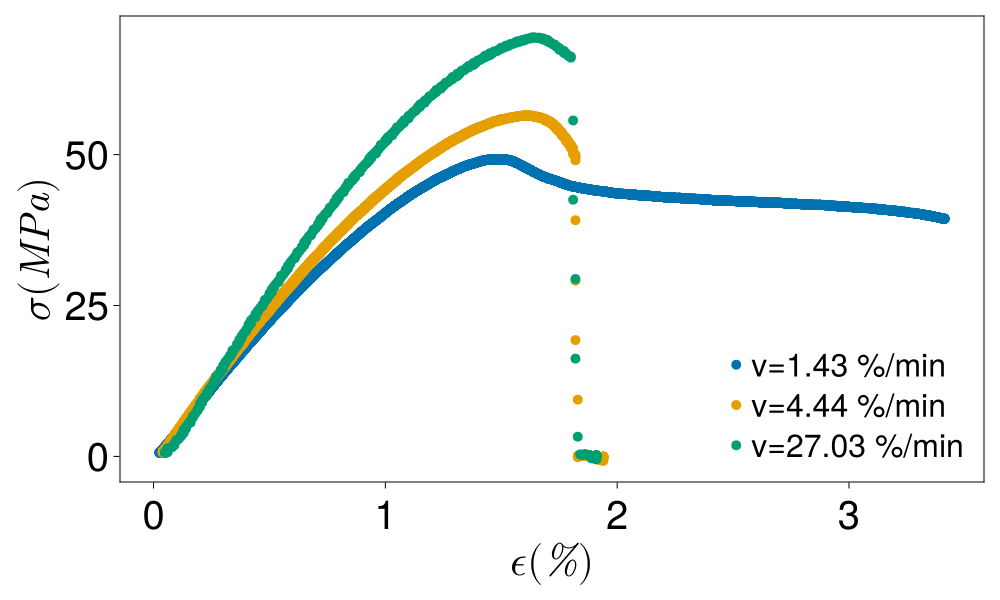

In [48]:
figStrainRate

### Vergleich 

In [62]:
figParylene = Figure(resolution = (1000, 600));

font=42
axParylene = Axis(figParylene[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 75)))


Axis with 0 plots:


In [63]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Parylene/Kang2013_9um_20T.csv"

df_Kang2013 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [64]:
    Makie.scatter!(axParylene,df_Kang2013[!,1],df_Kang2013[!,2];
      label = "Parylene v=1 %/min (Kang, 2013)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)
     #axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [65]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Parylene/Kohler2023.csv"

df_Kohler2023 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [66]:
  Makie.scatter!(axParylene,df_Kohler2023[!,1],df_Kohler2023[!,2];
      label = "Parylene v=1.25 %/min (Kohler, 2023)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
     #axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [67]:
    ##### Strain Rate 1.43 %/min

    BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
    name="251006-"
    df_Group=[]
    df_Group_Total=[]

    for i in [1]
            file_path = "$(BaseName)$(i).csv"
            df=import_TIRA(file_path)
            df[!,:Name]=fill("$(name)$(i)", nrow(df))
            df[!,:Stress]=df[!,:Kraft]*1e-6/As
              df[!,:Strain]=df[!,:Weg]/100
            df_filtered=filter_range(df,"Weg",0.01,50)
            push!(df_Group,df_filtered)
            push!(df_Group_Total,df_filtered)
    end

    df_Group
    push!(σ_exp,df_Group[1][!,:Stress]*1e6)
    push!(ϵ_exp,df_Group[1][!,:Strain])
    push!(dϵdt,0.0143/60)

5-element Vector{Any}:
 0.00023833333333333334
 0.00074
 0.0045049999999999995
 0.00023833333333333334
 0.00023833333333333334

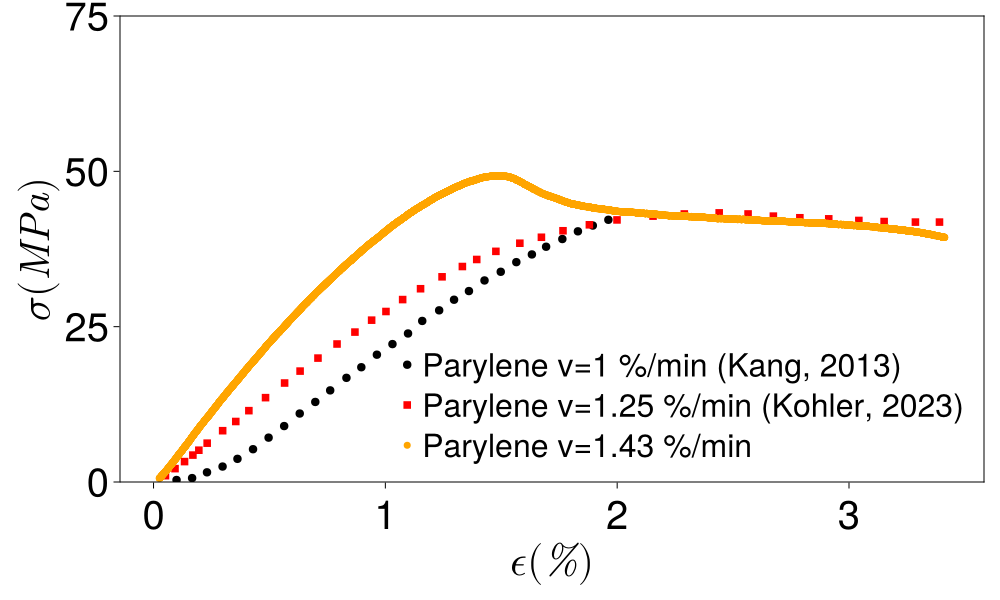

In [68]:
    Makie.scatter!(axParylene ,ϵ_exp[1]*100,σ_exp[1]/1e6;
     markersize=10, 
     label = "Parylene v=$(round(dϵdt[1]*60*100, digits=3)) %/min ",
     color = :orange,
     clip = true)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
     figParylene

In [125]:
    Makie.scatter!(ax1 ,ϵ_exp[1]*100,σ_exp[1]/1e6;
     markersize=6, 
     label = "Parylene v=$(round(dϵdt[1]*60*100, digits=3)) %/min ",
     color = :orange,
     clip = true)
     axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)

Legend()

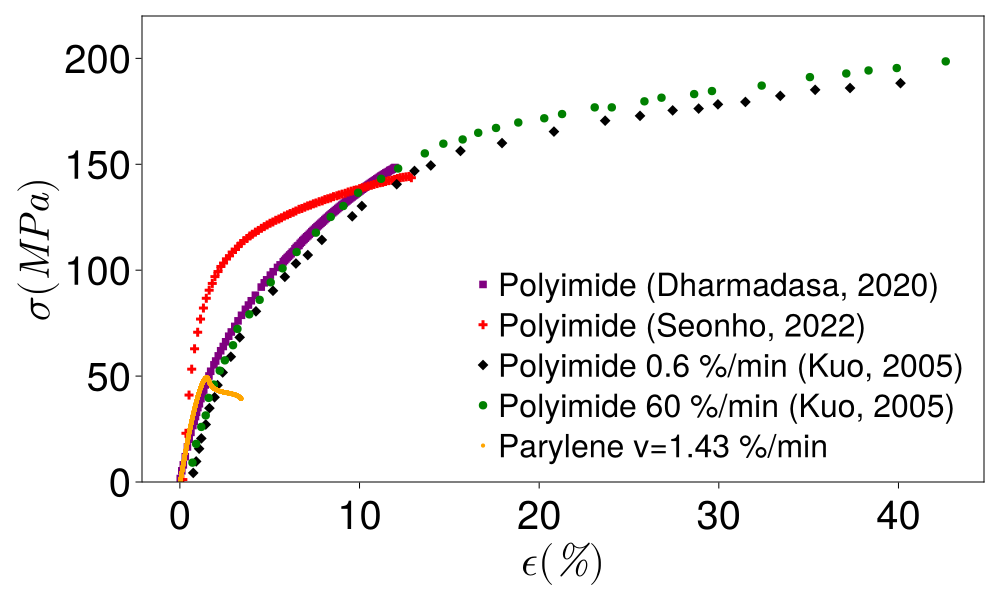

In [126]:
fig

## Fracture mechanics

In [98]:
figLaw = Figure(resolution = (1000, 600));

axLaw= Axis(figLaw[1,1],
    xlabel = L"logΔG (J/m2)",
    ylabel = L"log(\frac{\partial a}{\partial N}) (um/cycle)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


In [99]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/PI_Cu_Walter2018.csv"

df_Walter2018 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [100]:
df_Walter2018

Row,G(J/m2),dadN(mm/cycle)
,Float64,Float64
1,1.94953,6.18966e-7
2,2.00492,1.88365e-6
3,2.97231,5.20795e-6
4,3.00506,1.33352e-5
5,3.62208,0.000501187
6,3.71401,5.84341e-6
7,3.86085,6.81292e-5
8,4.03565,0.00121153
9,4.04527,1.0e-5


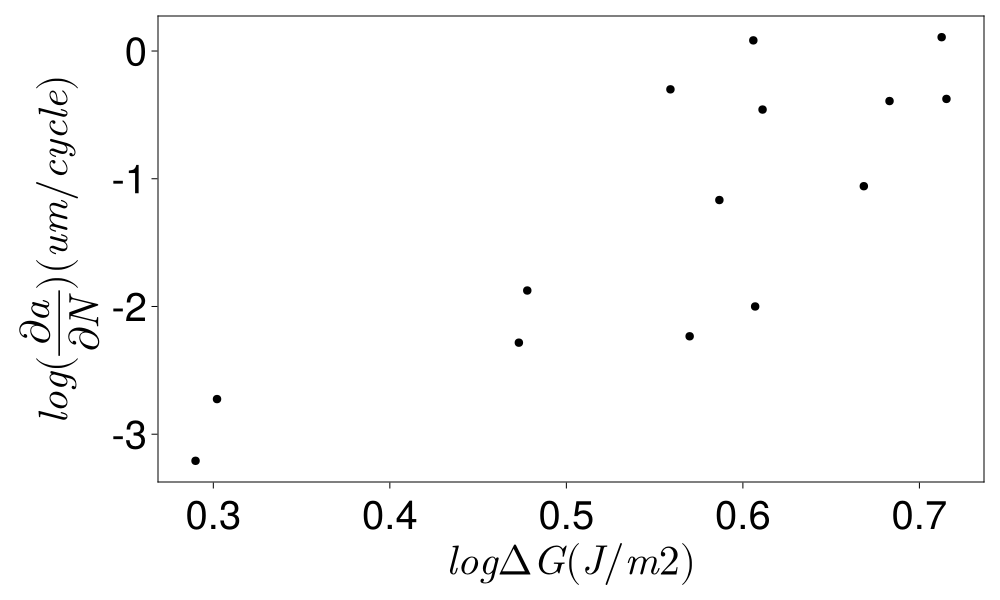

In [101]:
    Makie.scatter!(axLaw,log10.(df_Walter2018[!,1]),log10.(df_Walter2018[!,2]*1000);
      label = "PI-Cu (Walter, 2018)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      figLaw

In [79]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv"

df_Zhu2010 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

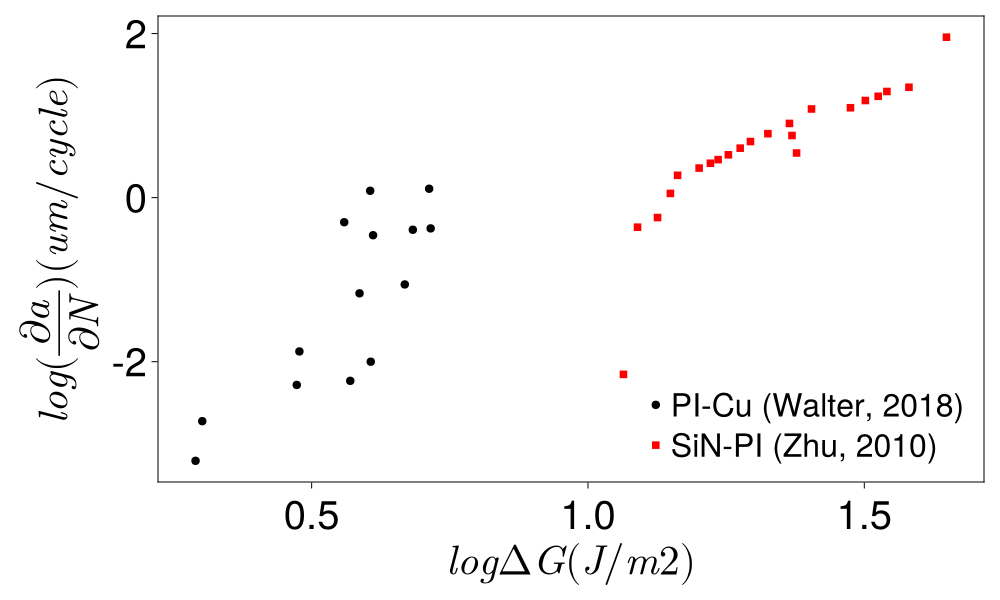

In [80]:
    Makie.scatter!(axLaw,log10.(df_Zhu2010[!,1]),log10.(df_Zhu2010[!,2]*100000);
      label = "SiN-PI (Zhu, 2010)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
      axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      figLaw

### Unsere Interfaces

In [93]:
figLaw = Figure(resolution = (1000, 600));

axLaw= Axis(figLaw[1,1],
    xlabel = L"logΔG (J/m2)",
    ylabel = L"log(\frac{\partial a}{\partial N}) (um/cycle)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


In [94]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv"

df_Zhu2010 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [95]:
    Makie.scatter!(axLaw,log10.(df_Zhu2010[!,1]),log10.(df_Zhu2010[!,2]*100000);
      label = "Si-PI (Zhu, 2010)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
      #axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [96]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SI_PY_AP5F10.csv"

df_AP5F10 = CSV.read(BaseName, DataFrame;
    delim=',',
    decimal='.'
);

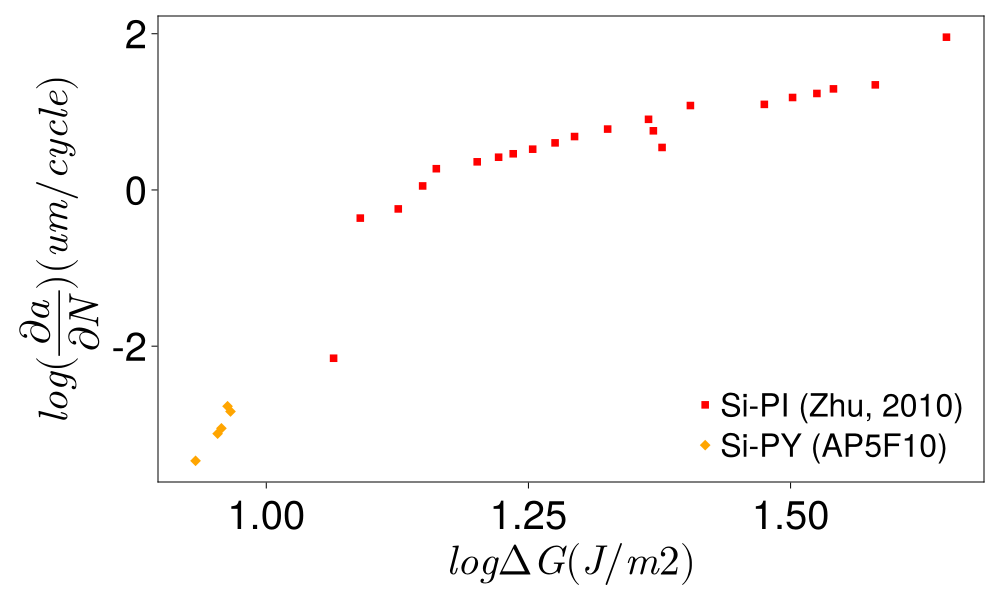

In [97]:
    Makie.scatter!(axLaw,log10.(df_AP5F10[!,1]),log10.(df_AP5F10[!,2]);
      label = "Si-PY (AP5F10) ",
      marksize=10,
      color = :orange,
      clip = true,
      marker = :diamond)
      axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      figLaw